# Conformal prediction para regressao

Conformal prediction transforma uma previsao pontual em um intervalo de predicao. A ideia e reservar uma parte dos dados para calibracao, observar os erros do modelo nessa parte e usar um quantil desses erros para montar os intervalos.

Para cobertura alvo de 90%, usamos `alpha = 0.10`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


## Dataset

Escolha um dos dois arquivos da pasta:

- `diabetes.csv`, alvo `disease_progression`
- `california_housing.csv`, alvo `median_house_value`

In [3]:
arquivo = "california_housing.csv"
alvo = "median_house_value"

# Para usar o outro dataset:
# arquivo = "diabetes.csv"
# alvo = "disease_progression"

alpha = 0.10

df = pd.read_csv(arquivo)
X = df.drop(columns=alvo)
y = df[alvo]

print(df.shape)
df.head()


(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Separando treino, calibracao e teste

O modelo aprende no treino. A calibracao fica separada para estimar o tamanho do erro. O teste fica para avaliar os intervalos no final.

In [4]:
X_treino_cal, X_teste, y_treino_cal, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_treino, X_cal, y_treino, y_cal = train_test_split(
    X_treino_cal, y_treino_cal, test_size=0.25, random_state=42
)

print("treino:", X_treino.shape)
print("calibracao:", X_cal.shape)
print("teste:", X_teste.shape)


treino: (12384, 8)
calibracao: (4128, 8)
teste: (4128, 8)


## Split conformal comum

No split conformal comum, todos os pontos recebem a mesma largura de intervalo:

`previsao +- q`

O valor `q` e um quantil dos erros absolutos no conjunto de calibracao.

In [5]:
modelo = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)

modelo.fit(X_treino, y_treino)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [6]:
pred_cal = modelo.predict(X_cal)
erros_cal = np.abs(y_cal - pred_cal)

n_cal = len(erros_cal)
nivel_quantil = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q = np.quantile(erros_cal, nivel_quantil, method="higher")

q


np.float64(0.7884205015262518)

In [8]:
pred_teste = modelo.predict(X_teste)

baixo_comum = pred_teste - q
alto_comum = pred_teste + q

cobertura_comum = ((y_teste >= baixo_comum) & (y_teste <= alto_comum)).mean()
largura_comum = np.mean(alto_comum - baixo_comum)
mae_comum = mean_absolute_error(y_teste, pred_teste)

pd.Series({
    "cobertura": cobertura_comum,
    "largura_media": largura_comum,
    "mae": mae_comum,
    "q": q,
})


cobertura        0.900194
largura_media    1.576841
mae              0.332465
q                0.788421
dtype: float64

## Split conformal com modelo de variancia

Agora a largura pode mudar de ponto para ponto. Usamos o conjunto de treino inteiro para treinar um modelo de media e, com os residuos desse modelo no proprio treino, treinamos outro modelo para prever o tamanho do erro.

Depois calibramos os erros normalizados:

`score = |y - previsao| / escala_prevista`

No teste, o intervalo fica:

`previsao +- q * escala_prevista`

In [9]:
modelo_media = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)

modelo_media.fit(X_treino, y_treino)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [10]:
pred_treino = modelo_media.predict(X_treino)
residuos = y_treino - pred_treino
variancia_observada = residuos ** 2

modelo_variancia = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)

modelo_variancia.fit(X_treino, variancia_observada)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
pred_cal_adapt = modelo_media.predict(X_cal)
escala_cal = np.sqrt(modelo_variancia.predict(X_cal))

scores_cal = np.abs(y_cal - pred_cal_adapt) / escala_cal

n_cal = len(scores_cal)
nivel_quantil = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q_adapt = np.quantile(scores_cal, nivel_quantil, method="higher")

q_adapt


np.float64(2.8118520548031394)

In [12]:
pred_teste_adapt = modelo_media.predict(X_teste)
escala_teste = np.sqrt(modelo_variancia.predict(X_teste))

baixo_adapt = pred_teste_adapt - q_adapt * escala_teste
alto_adapt = pred_teste_adapt + q_adapt * escala_teste

cobertura_adapt = ((y_teste >= baixo_adapt) & (y_teste <= alto_adapt)).mean()
largura_adapt = np.mean(alto_adapt - baixo_adapt)
mae_adapt = mean_absolute_error(y_teste, pred_teste_adapt)

comparacao = pd.DataFrame({
    "metodo": ["split comum", "com modelo de variancia"],
    "cobertura": [cobertura_comum, cobertura_adapt],
    "largura_media": [largura_comum, largura_adapt],
    "mae": [mae_comum, mae_adapt],
    "q": [q, q_adapt],
})

comparacao


,metodo,cobertura,largura_media,mae,q
0,split comum,0.900194,1.576841,0.332465,0.788421
1,com modelo de variancia,0.896076,1.425465,0.332465,2.811852


## Intervalos no teste

No metodo comum, a largura e fixa. No metodo com variancia, a largura muda conforme a escala prevista para cada ponto.

In [13]:
intervalos = pd.DataFrame({
    "y_real": y_teste,
    "pred_comum": pred_teste,
    "baixo_comum": baixo_comum,
    "alto_comum": alto_comum,
    "pred_variancia": pred_teste_adapt,
    "baixo_variancia": baixo_adapt,
    "alto_variancia": alto_adapt,
})

intervalos.head(10).round(2)


,y_real,pred_comum,baixo_comum,alto_comum,pred_variancia,baixo_variancia,alto_variancia
20046,0.48,0.51,-0.28,1.30,0.51,0.37,0.65
3024,0.46,0.86,0.08,1.65,0.86,0.26,1.47
15663,5.00,4.70,3.91,5.49,4.70,3.52,5.88
20484,2.19,2.47,1.68,3.26,2.47,1.99,2.95
9814,2.78,2.32,1.53,3.11,2.32,1.63,3.00
13311,1.59,1.84,1.06,2.63,1.84,1.25,2.44
7113,1.98,2.38,1.59,3.17,2.38,1.61,3.15
7668,1.58,1.66,0.87,2.45,1.66,1.45,1.87
18246,3.40,2.71,1.92,3.49,2.71,1.18,4.23
5723,4.47,4.83,4.04,5.62,4.83,3.92,5.74


## Exemplo sintetico com variancia mudando

Agora vamos usar dados em que o ruido depende de `abs(x)`. Primeiro olhamos os dados puros, depois fazemos o split, depois aplicamos cada metodo separadamente.

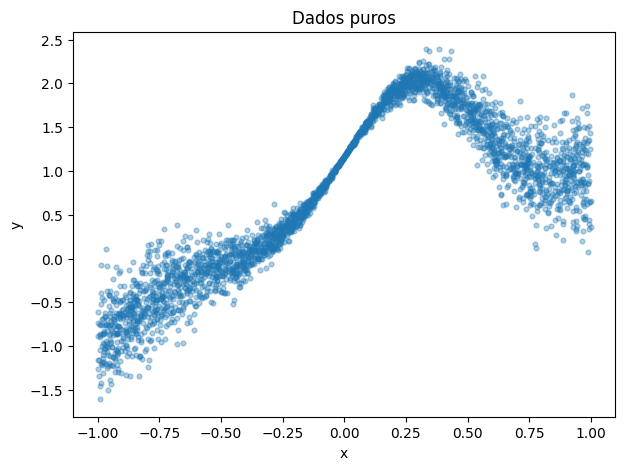

,x,y
0,-0.250920,0.400991
1,0.901429,1.155430
2,0.463988,1.912883
3,0.197317,1.790742
4,-0.687963,-0.028065


In [14]:
np.random.seed(42)

n = 3000
std_dev = 0.35

x = np.random.uniform(low=-1, high=1, size=n)
y = (x**3) + 2 * np.exp(-6 * (x - 0.3)**2)
y = y + np.random.normal(scale=std_dev * np.abs(x), size=n)
df_sintetico = pd.DataFrame({'x': x, 'y': y})

plt.figure(figsize=(7, 5))
plt.scatter(df_sintetico["x"], df_sintetico["y"], s=12, alpha=0.35)
plt.title("Dados puros")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

df_sintetico.head()


## Split dos dados sinteticos

Vamos separar treino, calibracao e teste. O treino ajusta o modelo, a calibracao escolhe o quantil e o teste avalia os intervalos.

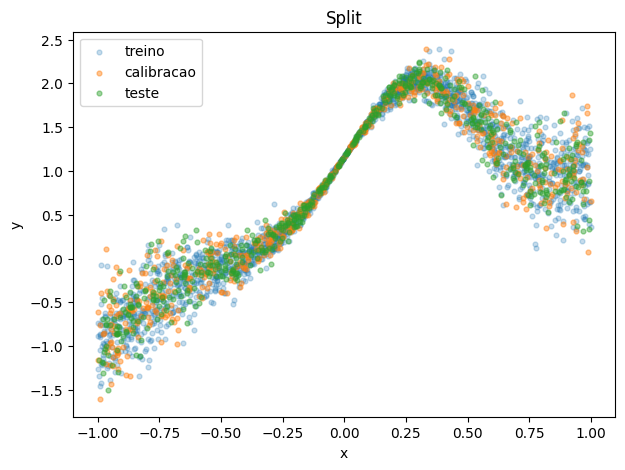

treino: (1800, 1)
calibracao: (600, 1)
teste: (600, 1)


In [15]:
X_s = df_sintetico[["x"]]
y_s = df_sintetico["y"]

X_treino_cal_s, X_teste_s, y_treino_cal_s, y_teste_s = train_test_split(
    X_s, y_s, test_size=0.20, random_state=42
)

X_treino_s, X_cal_s, y_treino_s, y_cal_s = train_test_split(
    X_treino_cal_s, y_treino_cal_s, test_size=0.25, random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X_treino_s["x"], y_treino_s, s=12, alpha=0.25, label="treino")
plt.scatter(X_cal_s["x"], y_cal_s, s=12, alpha=0.45, label="calibracao")
plt.scatter(X_teste_s["x"], y_teste_s, s=12, alpha=0.45, label="teste")
plt.title("Split")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print("treino:", X_treino_s.shape)
print("calibracao:", X_cal_s.shape)
print("teste:", X_teste_s.shape)


## CP comum no exemplo sintetico

O split conformal comum usa uma largura unica para todos os pontos.

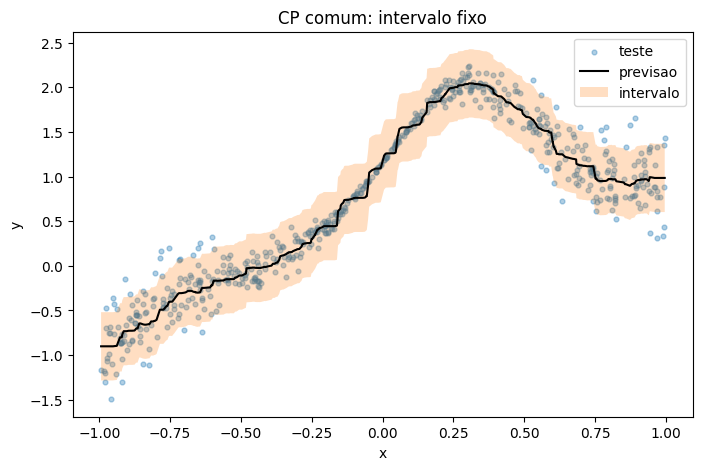

cobertura        0.928333
largura_media    0.765093
mae              0.139701
q                0.382547
dtype: float64

In [16]:
modelo_s = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=30,
    n_jobs=-1,
    random_state=42,
)

modelo_s.fit(X_treino_s, y_treino_s)

pred_cal_s = modelo_s.predict(X_cal_s)
erros_cal_s = np.abs(y_cal_s - pred_cal_s)

n_cal_s = len(erros_cal_s)
nivel_quantil_s = np.ceil((n_cal_s + 1) * (1 - alpha)) / n_cal_s
q_s = np.quantile(erros_cal_s, nivel_quantil_s, method="higher")

pred_teste_s = modelo_s.predict(X_teste_s)
baixo_comum_s = pred_teste_s - q_s
alto_comum_s = pred_teste_s + q_s

cobertura_comum_s = ((y_teste_s >= baixo_comum_s) & (y_teste_s <= alto_comum_s)).mean()
largura_comum_s = np.mean(alto_comum_s - baixo_comum_s)
mae_comum_s = mean_absolute_error(y_teste_s, pred_teste_s)

ordem_s = np.argsort(X_teste_s["x"].to_numpy())
x_plot_s = X_teste_s["x"].to_numpy()[ordem_s]
y_plot_s = y_teste_s.to_numpy()[ordem_s]

plt.figure(figsize=(8, 5))
plt.scatter(x_plot_s, y_plot_s, s=12, alpha=0.35, label="teste")
plt.plot(x_plot_s, pred_teste_s[ordem_s], color="black", label="previsao")
plt.fill_between(x_plot_s, baixo_comum_s[ordem_s], alto_comum_s[ordem_s], alpha=0.25, label="intervalo")
plt.title("CP comum: intervalo fixo")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

resultado_comum_s = pd.Series({
    "cobertura": cobertura_comum_s,
    "largura_media": largura_comum_s,
    "mae": mae_comum_s,
    "q": q_s,
})

resultado_comum_s


## CP com modelo de variancia no exemplo sintetico

Agora usamos os residuos no treino para estimar a variancia. A largura do intervalo passa a depender de `x`.

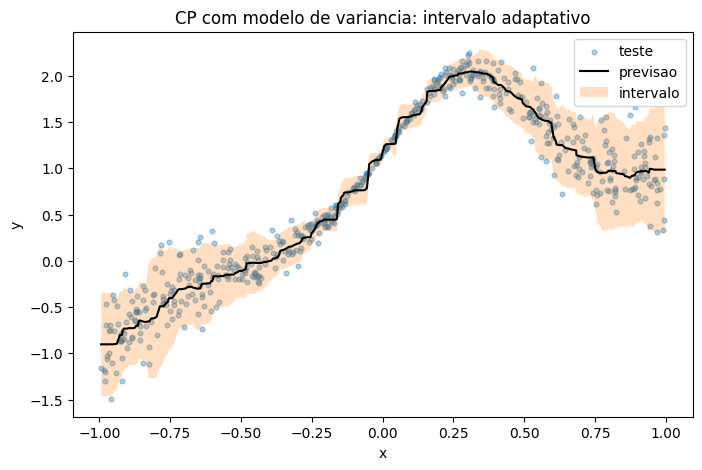

,metodo,cobertura,largura_media,mae,q
0,split comum,0.928333,0.765093,0.139701,0.382547
1,com modelo de variancia,0.918333,0.662495,0.139701,1.875786


In [17]:
modelo_media_s = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=30,
    n_jobs=-1,
    random_state=42,
)

modelo_media_s.fit(X_treino_s, y_treino_s)

pred_treino_s = modelo_media_s.predict(X_treino_s)
residuos_s = y_treino_s - pred_treino_s
variancia_observada_s = residuos_s ** 2

modelo_variancia_s = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=30,
    n_jobs=-1,
    random_state=42,
)

modelo_variancia_s.fit(X_treino_s, variancia_observada_s)

pred_cal_adapt_s = modelo_media_s.predict(X_cal_s)
escala_cal_s = np.sqrt(modelo_variancia_s.predict(X_cal_s))
scores_cal_s = np.abs(y_cal_s - pred_cal_adapt_s) / escala_cal_s

q_adapt_s = np.quantile(scores_cal_s, nivel_quantil_s, method="higher")

pred_teste_adapt_s = modelo_media_s.predict(X_teste_s)
escala_teste_s = np.sqrt(modelo_variancia_s.predict(X_teste_s))

baixo_adapt_s = pred_teste_adapt_s - q_adapt_s * escala_teste_s
alto_adapt_s = pred_teste_adapt_s + q_adapt_s * escala_teste_s

cobertura_adapt_s = ((y_teste_s >= baixo_adapt_s) & (y_teste_s <= alto_adapt_s)).mean()
largura_adapt_s = np.mean(alto_adapt_s - baixo_adapt_s)
mae_adapt_s = mean_absolute_error(y_teste_s, pred_teste_adapt_s)

plt.figure(figsize=(8, 5))
plt.scatter(x_plot_s, y_plot_s, s=12, alpha=0.35, label="teste")
plt.plot(x_plot_s, pred_teste_adapt_s[ordem_s], color="black", label="previsao")
plt.fill_between(x_plot_s, baixo_adapt_s[ordem_s], alto_adapt_s[ordem_s], alpha=0.25, label="intervalo")
plt.title("CP com modelo de variancia: intervalo adaptativo")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

comparacao_sintetico = pd.DataFrame({
    "metodo": ["split comum", "com modelo de variancia"],
    "cobertura": [cobertura_comum_s, cobertura_adapt_s],
    "largura_media": [largura_comum_s, largura_adapt_s],
    "mae": [mae_comum_s, mae_adapt_s],
    "q": [q_s, q_adapt_s],
})

comparacao_sintetico
